In [ ]:
%load_ext autoreload
%autoreload 2

import time
# from auto_robot_design.pinokla.closed_loop_kinematics import closedLoopProximalMount
from testing_ground.singular_hell.prox_custom import closedLoopProximalMount_open_support

from auto_robot_design.pinokla.calc_criterion import search_workspace
from pinocchio.visualize import MeshcatVisualizer
import meshcat
import numpy as np
from itertools import product
import matplotlib.pyplot as plt

import pinocchio as pin
from auto_robot_design.pinokla.closed_loop_kinematics import ForwardK
from auto_robot_design.pinokla.closed_loop_jacobian import jacobian_constraint

from auto_robot_design.description.builder import ParametrizedBuilder, DetailedURDFCreatorFixedEE, jps_graph2pinocchio_robot
from auto_robot_design.generator.restricted_generator.two_link_generator import TwoLinkGenerator

from auto_robot_design.generator.restricted_generator.two_link_generator import TwoLinkGenerator
from auto_robot_design.description.utils import draw_joint_point
import networkx as nx

from auto_robot_design.description.builder import add_branch
from auto_robot_design.description.kinematics import JointPoint

In [2]:
# link_mounts = {
#     'L1': [[0., 0.], [0., -0.15], 'G', True],
#     'L2': [[0., -0.15], [0., -0.3], 'L1', False],
#     }
# equalities = [
#     # [[0.0, -0.074], 'L3', 'L6'],
#     # [[0.0, -0.22399999999999998], 'L4', 'L5'],
# ]
# trackpoints = [
#     [[0., -0.3], 'L2'],
# ]
# link_mounts = {
#     'L8': [[-0.1, 0.0], [-0.11151828996322964, -0.046192388155425125], 'G', True],
#     'L7': [[-0.11151828996322964, -0.046192388155425125], [-0.087, -0.087], 'L8', False],
#     'L5': [[-0.087, -0.087], [0.0, -0.22399999999999998], 'L7', False],
#     'L5_2': [[0.0, -0.22399999999999998], [-0.040807611844574876, -0.09851828996322964], 'L5', None],
#     'L5_3': [[-0.040807611844574876, -0.09851828996322964], [-0.087, -0.087], 'L5', None],
#     'L6': [[-0.040807611844574876, -0.09851828996322964], [0.0, -0.074], 'L5', False],
#     'L3': [[0.0, 0.0], [0.0, -0.074], 'G', True],
#     'L3_2': [[0.0, -0.074], [0.0, -0.148], 'L3', None],
#     'L3_3': [[0.0, -0.148], [0.0, 0.0], 'L3', None],
#     'L4': [[0.0, -0.148], [0.0, -0.3], 'L3', False],
#     'L4_2': [[0.0, -0.3], [0.0, -0.22399999999999998], 'L4', None],
#     'L4_3': [[0.0, -0.22399999999999998], [0.0, -0.148], 'L4', None],
#     }
# equalities = [
#     [[0.0, -0.074], 'L3', 'L6'],
#     [[0.0, -0.22399999999999998], 'L4', 'L5'],
# ]
# trackpoints = [
#     [[0.0, -0.3], 'L4'],
# ]

#DOES NOT WORK FOR KIN GRAPH CONVERSION, JOINTS OVERLAP
# link_mounts = {
# 'L6': [[-0.1, 0.0], [-0.15000000000000002, -0.11199999999999999], 'G', True],
# 'L5': [[-0.15000000000000002, -0.11199999999999999], [0.0, -0.22399999999999998], 'L6', False],
# 'L3': [[0.0, 0.0], [0.0, -0.148], 'G', True],
# 'L4': [[0.0, -0.148], [0.0, -0.22399999999999998], 'L3', False],
# 'L4_2': [[0.0, -0.22399999999999998], [0.0, -0.3], 'L4', None],
# 'L4_3': [[0.0, -0.3], [0.0, -0.148], 'L4', None],
# }
# equalities = [
# [[0.0, -0.22399999999999998], 'L4', 'L5'],
# ]
# trackpoints = [
# [[0.0, -0.3], 'L4'],
# ]


# 5 BAR
base_w = 0.4
knee_w = 0.6
knee_h = 0.3
tip_h = 0.55
pr1 = [base_w/2, 0]
pl1 = [-base_w/2, 0]

pr2 = [knee_w/2, -knee_h]
pl2 = [-knee_w/2, -knee_h]
pc = [0, -tip_h]
link_mounts = {1:[pr1, pl1, 'G', None, -.15],
              2:[pr1, pr2, 1, True],
              3:[pr2, pc, 2, False],
              4:[pl1, pl2, 1, True],
              5:[pl2, pc, 4, False]}
equalities = [[pc, 5, 3, 0.03]]
# pc2 = [0.07, -tip_h]
trackpoints = [[pc, 5, 0.05]]


# TWO BAR
# base_w = 0.4
# knee_w = 0.6
# knee_h = 0.3
# tip_h = 0.55

# pr1 = [base_w/2, 0]
# pr2 = [knee_w/2, -knee_h]
# pl1 = [-base_w/2, 0]
# pc = [0, -tip_h]

# link_mounts = {#1:[pr1, pl1, 0, None],
#             1:[pr1, pr2, 0, True],
#             2:[pr2, pc, 1, True]}
# equalities = []
# trackpoints = [[pc, 2, 0.05]]

In [3]:
# # paths = {k:v[2] for k,v in link_mounts.items()}
# paths = [(k,v[2]) for k,v in link_mounts.items()]

# G = nx.Graph()
# # print(paths)

# for path in paths:
#     # print(path)
#     nx.add_path(G, path)

# for j in G.edges():
#     print(j)

# jaxis = np.array([0, 1, 0])

# tp = trackpoints[0]
# jpos = tp[0]
# name = tp[1]

# assert len(jpos) == 2
# jp_pos = np.array([jpos[0], 0, jpos[1]])
# current_jp = JointPoint(r=jp_pos, w=jaxis, name='EE', attach_endeffector=True)


# # Ginv = nx.line_graph(G)
# # Ginv.add_node('EE')
# G.add_edge('EE', name)
# Ginv = nx.line_graph(G)

# # nx.draw(G, node_size=500, with_labels=True)
# nx.draw(Ginv, node_size=500, with_labels=True)
# plt.show()

In [ ]:
from testing_ground.singular_hell.mj2jp import build_jp


graph_jp, _ = build_jp(link_mounts, equalities, trackpoints)

for j in graph_jp.nodes():
    print(j)

# draw_joint_point(graph_jp)
# plt.show()

# nx.draw(gj, node_size=500, with_labels=True)
# plt.show()

# nx.draw(gkin, node_size=500, with_labels=True)
# plt.show()

{'G': 'G', 1: 'G', 2: 2, 3: 3, 4: 4, 5: 5}
G
2
3
4
5
JointPoint(r=array([0.2, 0. , 0. ]), w=array([0, 1, 0]), active=True, attach_ground=True, attach_endeffector=False, name='2-1', instance_counter=0)
JointPoint(r=array([ 0.3,  0. , -0.3]), w=array([0, 1, 0]), active=False, attach_ground=False, attach_endeffector=False, name='3-2', instance_counter=0)
JointPoint(r=array([-0.2,  0. ,  0. ]), w=array([0, 1, 0]), active=True, attach_ground=True, attach_endeffector=False, name='4-1', instance_counter=0)
JointPoint(r=array([-0.3,  0. , -0.3]), w=array([0, 1, 0]), active=False, attach_ground=False, attach_endeffector=False, name='5-4', instance_counter=0)
JointPoint(r=array([ 0.  ,  0.  , -0.55]), w=array([0, 1, 0]), active=False, attach_ground=False, attach_endeffector=False, name='5-3', instance_counter=0)
JointPoint(r=array([ 0.  ,  0.  , -0.56]), w=array([0, 1, 0]), active=False, attach_ground=False, attach_endeffector=True, name='jEE', instance_counter=0)


In [5]:
# gen = TwoLinkGenerator()
# graphs_and_cons = gen.get_standard_set()

# graph_jp, __ = graphs_and_cons[0]

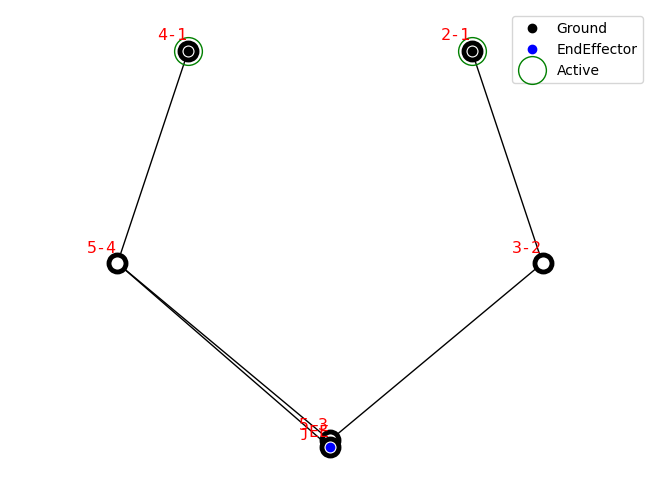

In [6]:
draw_joint_point(graph_jp)
plt.show()

link G
direct call
defining geom
link EE
direct call
defining geom
link 
direct call
defining geom
link 
direct call
defining geom
3
link 
direct call
defining geom
link 
direct call
defining geom
EE


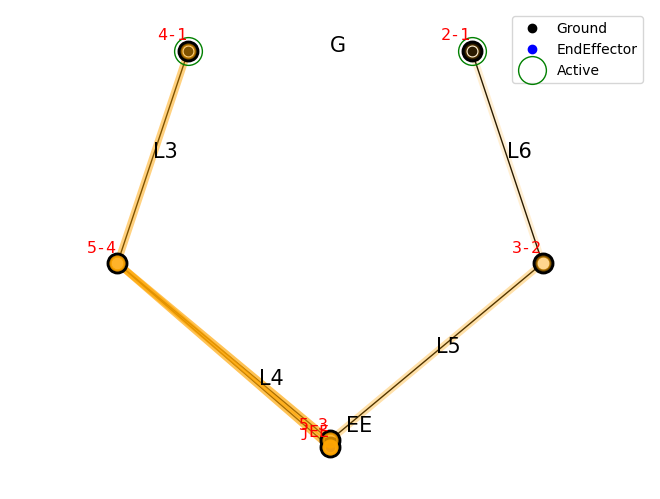

defining geom
defining geom
3
defining geom
defining geom


In [99]:
from auto_robot_design.description.mechanism import JointPoint2KinematicGraph
from auto_robot_design.description.utils import draw_links

is_showed=1

kinematic_graph = JointPoint2KinematicGraph(graph_jp)
EFFECTOR_NAME = kinematic_graph.EE.name
print(kinematic_graph.EE.name)

if is_showed:
    draw_links(kinematic_graph, graph_jp)
    plt.show()
# # draw_kinematic_graph(kinematic_graph)
# main_branch = kinematic_graph.define_main_branch()
# # draw_kinematic_graph(main_branch)
# kin_tree = kinematic_graph.define_span_tree()

# thickness = 0.04
# density = 2700 / 2.8
# for n in kinematic_graph.nodes():
#     n.thickness = thickness
#     n.density = density

# for j in kinematic_graph.joint_graph.nodes():
#     j.pos_limits = (-np.pi, np.pi)
#     if j.jp.active:
#         j.actuator = TMotor_AK80_9()
#     j.damphing_friction = (0.05, 0)
    
# kinematic_graph.define_link_frames()

kinematic_graph.define_main_branch()
kinematic_graph.define_span_tree()

kinematic_graph.define_link_frames()

In [100]:
for j in kinematic_graph.joint_graph.nodes():
    print(j.jp.name)
    # print(j.frame)
    print([l.name for l in j.links])
    print([l.frame for l in j.links])
# for

2-1
['G', 'L6']
[array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]]), array([[-0.9486833 ,  0.        ,  0.31622777,  0.2       ],
       [ 0.        ,  1.        ,  0.        ,  0.        ],
       [-0.31622777,  0.        , -0.9486833 ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  1.        ]])]
3-2
['L6', 'L5']
[array([[-0.9486833 ,  0.        ,  0.31622777,  0.2       ],
       [ 0.        ,  1.        ,  0.        ,  0.        ],
       [-0.31622777,  0.        , -0.9486833 ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  1.        ]]), array([[-0.6401844 , -0.        , -0.76822128,  0.3       ],
       [ 0.        ,  1.        , -0.        ,  0.        ],
       [ 0.76822128,  0.        , -0.6401844 , -0.3       ],
       [ 0.        ,  0.        ,  0.        ,  1.        ]])]
4-1
['G', 'L3']
[array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]]), array(

In [ ]:
# gen = TwoLinkGenerator()

# # graphs_and_cons = gen.get_standard_set()
# # graph_jp, __ = graphs_and_cons[0]

# gen.build_standard_two_linker()
# graph_jp = gen.graph

# np.set_printoptions(precision=3, linewidth=300, suppress=True, threshold=10000)
# builder = ParametrizedBuilder(DetailedURDFCreatorFixedEE)

# # robo, robo_free = jps_graph2pinocchio_robot(graph_jp, builder)

# # q0 = closedLoopProximalMount_open_support(
# #     robo.model,
# #     robo.data,
# #     robo.constraint_models,
# #     robo.constraint_data,
# #     max_it=100,
# # )

In [102]:
# draw_joint_point(graph_jp)

In [103]:
# for j1,j2 in graph_jp.edges():
#     # if not kinematic_graph.EE in j.links:
#     # print([l.name for l in list(j.links)])
#     print(j1.name, j2.name)

# for j in graph_jp.nodes():
#     print(j)

In [7]:
builder = ParametrizedBuilder(DetailedURDFCreatorFixedEE)
robo, robo_free = jps_graph2pinocchio_robot(graph_jp, builder)


viz = MeshcatVisualizer(robo.model, robo.visual_model, robo.visual_model)
# viz.viewer = meshcat.Visualizer().open()
# viz.clean()
# viz.loadViewerModel()
viz.initViewer(loadModel=True)

link G
direct call
defining geom
link EE
direct call
defining geom
link 
direct call
defining geom
link 
direct call
defining geom
3
link 
direct call
defining geom
link 
direct call
defining geom
defining geom
defining geom
3
defining geom
defining geom
defining geom
defining geom
defining geom
defining geom
defining geom
3
defining geom
You can open the visualizer by visiting the following URL:
http://127.0.0.1:7000/static/


In [ ]:
# q0 = closedLoopProximalMount_open_support(
#     robo.model,
#     robo.data,
#     robo.constraint_models,
#     robo.constraint_data,
#     max_it=100,
# )

q0 = np.array([0,0,0,2,0])

viz.display(q0)

In [9]:
EFFECTOR_NAME = "EE"
BASE_FRAME = "G"
LINK_FRAMES = ['L6','L5','L3','L4'] # ee is last

In [10]:
from testing_ground.singular_hell.prox_custom import angle_wrap


q_space_mot_1 = angle_wrap(np.linspace(-np.pi, np.pi, 30, endpoint=False))
q_space_mot_2 = angle_wrap(np.linspace(-np.pi, np.pi, 30, endpoint=False))
# q_space_mot_1 = np.concatenate((np.linspace(0, np.pi, 40, endpoint=False),
#                                np.linspace(-np.pi, 0, 40, endpoint=False)[::-1])) #best for no hist 150 it with reorder?
# q_space_mot_2 = np.concatenate((np.linspace(0, np.pi, 40, endpoint=False),
#                                np.linspace(-np.pi, 0, 40, endpoint=False)[::-1]))
# q_space_mot_2 = np.linspace(0, 2*np.pi, 80, endpoint=False)
# q_space_mot_1 = np.linspace(np.pi/2, np.pi, 5)
# q_space_mot_2 = np.linspace(np.pi, -np.pi, 20)

# q_space_mot_1 = np.asarray([0])
# q_space_mot_2 = np.asarray([np.pi/10, -0.559]) # Forw sing
# q_space_mot_1 = np.asarray([0])
# q_space_mot_2 = np.asarray([np.pi/10, np.pi/7.4]) # back sing
# q_space_mot_1 = np.asarray([0, -1.63])
# q_space_mot_2 = np.asarray([-0.52]) # back sing mega
# q_mot_double_space = list(product(q_space_mot_1, q_space_mot_2))

qm = []#np.empty(len(q_space_mot_1)*len(q_space_mot_2)) #q_mot_double_space
for i, m1 in enumerate(q_space_mot_1): 
    for j, m2 in enumerate(q_space_mot_2[::-1] if i%2 else q_space_mot_2):
        qm.append((m1, m2))
# for qmi in qm:
#     print(qmi)
q_mot_double_space = qm

# print(q0)
# print(angle_wrap(np.array([0,0.9*np.pi,np.pi,1.9*np.pi,2*np.pi])))

In [11]:
hasattr(viz.viewer, 'jupyter_cell') and viz.viewer.jupyter_cell()

In [12]:
from testing_ground.singular_hell.prox_custom import search_workspace_FK


free_jigg = [0, np.pi]#[-2*np.pi/3, 0, 2*np.pi/3]
workspace_xyz, available_q, jacs6d, jacsC6d, Ldsdq_6d, Lambdas, repeaters = search_workspace_FK(robo.model, robo.data, EFFECTOR_NAME, BASE_FRAME, np.array(
    q_mot_double_space), robo.actuation_model, robo.constraint_models, robo.constraint_data, viz, LINK_FRAMES, free_jiggle=free_jigg)
print("Coverage q " + str(len(available_q)/(len(q_mot_double_space))))

[ 3.14159265  2.25580502  1.38525674 -2.93215314 -2.85156306]
[ 3.14159265  2.25580502  1.38525674 -2.93215314 -2.85156306]
[ 3.14159265 -1.6719492   2.03285785 -2.72271363 -0.05797037]
[ 3.14159265  1.7503852   1.47137435 -2.72271363  2.80288053]
[ 3.14159265 -2.25292423  2.07021885 -2.51327412 -0.81102391]
[ 3.14159265 -2.25292423  2.07021885 -2.51327412 -0.81102391]
[ 3.14159265 -2.61298284  2.20111738 -2.30383461 -1.2496235 ]
[ 3.14159265  0.96135765  1.13602102 -2.0943951   1.05018112]
[ 3.14159265  1.16172253  0.77029165 -1.67551608  0.46593761]
[ 3.14159265 -3.00332164  2.92119175 -1.46607657 -1.75764597]
[ 3.14159265 -3.03175719  3.10827574 -1.25663706 -1.80843704]
[ 3.14159265  1.63203031  0.21057985 -1.04719755 -0.25178495]
[ 3.14159265  1.8018378   0.02854928 -0.83775804 -0.47344753]
[ 3.14159265 -3.0690699  -2.63097728 -0.62831853 -1.930136  ]
[ 3.14159265  2.14161362 -0.31575993 -0.41887902 -0.89685994]
[ 3.14159265 -3.05786116 -2.30934932 -0.20943951 -2.01617831]
[ 3.1415

In [ ]:
# import sys
# sys.path.append('d:/Soft/LGS-mujoco')
# sys.path.append('d:/Soft/LGS-mujoco/creative_mess')

# import LGS_mujoco
# from creative_mess import optim_2sem_sing
# from creative_mess.optim_2sem_sing import plot_fsing
from drafts.optim_2sem_sing import plot_colored_points, plot_fsing_tall, calc_least_SV



In [14]:
print(Ldsdq_6d)

[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [],

In [15]:
# jcons_cut = [ar[(0,2),:] for ar in jacsC6d]
# jcons_cut = jacsC6d
# jcons_cut = jacs6d
from testing_ground.singular_hell.prox_custom import calc_dqdmot


jcons_cut = [ar[(0,2),:] for ar in jacs6d] # seems like edges of ee space

singvals2ik = calc_least_SV(jcons_cut)
sing_prox2ik = 1/singvals2ik
# sing_prox2ik = singvals2ik
# lowest_clip = 1e-3
# highest_clip = 1e3
# sing_prox2ik = np.clip(sing_prox2ik, a_min=lowest_clip, a_max=highest_clip)

list_dmotdq = []
for i in range(len(jacsC6d)):
    Jmot, Jfree = jacsC6d[i][0]
    dqdmot = calc_dqdmot(Jmot, Jfree, robo.actuation_model)
    dmotdq = np.linalg.pinv(dqdmot)
    list_dmotdq.append(dmotdq)

singvals2fk = calc_least_SV(list_dmotdq)
sing_prox_fk = 1/singvals2fk

In [16]:
# print(available_q.shape)
print(sing_prox2ik)
print(np.min(sing_prox2ik), np.max(sing_prox2ik))

[1.11284608e+01 7.65596896e+00 1.68077763e+01 4.91084349e+00
 5.61049394e+00 2.49457349e+01 5.84319052e+00 1.55227023e+01
 2.05243789e+01 1.01496924e+01 2.19342974e+01 9.58642080e+01
 1.57509947e+01 5.96794622e+01 7.33800807e+00 7.65408985e+00
 1.17810334e+01 8.38847329e+00 1.82357111e+01 2.78649036e+01
 4.88607141e+01 1.39948303e+02 4.29185174e+00 4.91403540e+00
 6.26023808e+00 2.20839653e+01 1.51681953e+01 1.19607599e+01
 9.32183737e+00 7.96099838e+00 8.07982830e+00 9.83942663e+00
 4.86200813e+00 1.41478124e+01 3.98590237e+00 4.16771272e+00
 4.65422519e+00 5.64306079e+00 2.22797271e+01 8.28669105e+00
 1.90652900e+01 1.76023722e+01 1.77245973e+01 2.95753103e+02
 1.37781005e+01 1.18681687e+01 6.25935457e+00 8.57628484e+00
 6.49970375e+00 6.10085908e+00 5.20030584e+00 4.63439550e+00
 6.86780930e+00 6.63968924e+00 1.79446035e+01 3.16319252e+02
 1.12703588e+01 2.99885975e+01 6.18811214e+00 7.67784283e+00
 6.31284977e+00 1.10379668e+01 4.90784376e+00 7.94154658e+00
 5.37585311e+00 6.968132

In [17]:
def plot_fsing(available_xyz, motorspace_q, sing_prox2ik, is_log=False, color_lims=[1.5, 4], title="Близость сингулярности"):
    # color_lims = [1.5, 4]
    # color_lims = [.8, 1.5]
    dataq = np.asarray(motorspace_q)/np.pi*180
    dataee = np.asarray(available_xyz)
    fig = plt.figure(figsize=(10, 4.8), dpi=150) #6.4 4.8
    plt.suptitle(title)
    
    ax = fig.add_subplot(1, 2, 1)
    sc1 = plot_colored_points(ax, dataee[:,0], dataee[:,2], sing_prox2ik, 
    "Рабочее пространство", "X [м]", "Z [м]", is_log=is_log, add_cbar=0, 
    color_lims=color_lims, 
    )

    ax2 = fig.add_subplot(1, 2, 2)
    plot_colored_points(ax2, dataq[:,0], dataq[:,1], sing_prox2ik, 
    "Конфигурационное пространство", "Угол мотора 1, [градусы]", "Угол мотора 2 [градусы]", #[-180,180],[-180,180],
    # ticks=np.arange(-180, 181, step=45), 
    color_lims=color_lims, add_cbar=0,
    is_log=is_log)

    fig.subplots_adjust(right=.9)
    cax = fig.add_axes([0.91, 0.125, 0.02, 0.73])
    # divider = make_axes_locatable(ax)
    # cax = divider.append_axes('right', size='5%', pad=0.05)
    bar = fig.colorbar(mappable=sc1,cax=cax)#,ax=axs.ravel().tolist())

    bar = ax.collections[0].colorbar
    # if color_lims is not None:
    #     bar.set_ticks([color_lims[0], color_lims[1]])
    #     bar.set_ticklabels(['Дальше', 'Ближе'])
    # else:

    # bar.set_ticks([])
    bar.set_label('Близость сингулярности')

    # cax = fig.add_subplot(1,3,3)
    # cax = fig.add_axes([ax2.get_position().x1+0.01,ax2.get_position().y0,0.02,ax2.get_position().height])

    # bar = plt.colorbar(ax=ax, shrink=0.4)
    # plt.tight_layout()
    # bar=plt.colorbar()
    # plt.setp(bar.ax.get_yticklabels()[::2], visible=False)
    # for label in bar.ax.yaxis.get_ticklabels()[::2]:
    #     label.set_visible(False)

    plt.show()

In [18]:
from testing_ground.singular_hell.prox_custom import select_max_from_repeaters


maxed_idxs_ik = select_max_from_repeaters(sing_prox2ik, repeaters)

In [19]:
for r in repeaters:
    if r<1:
        print(r)

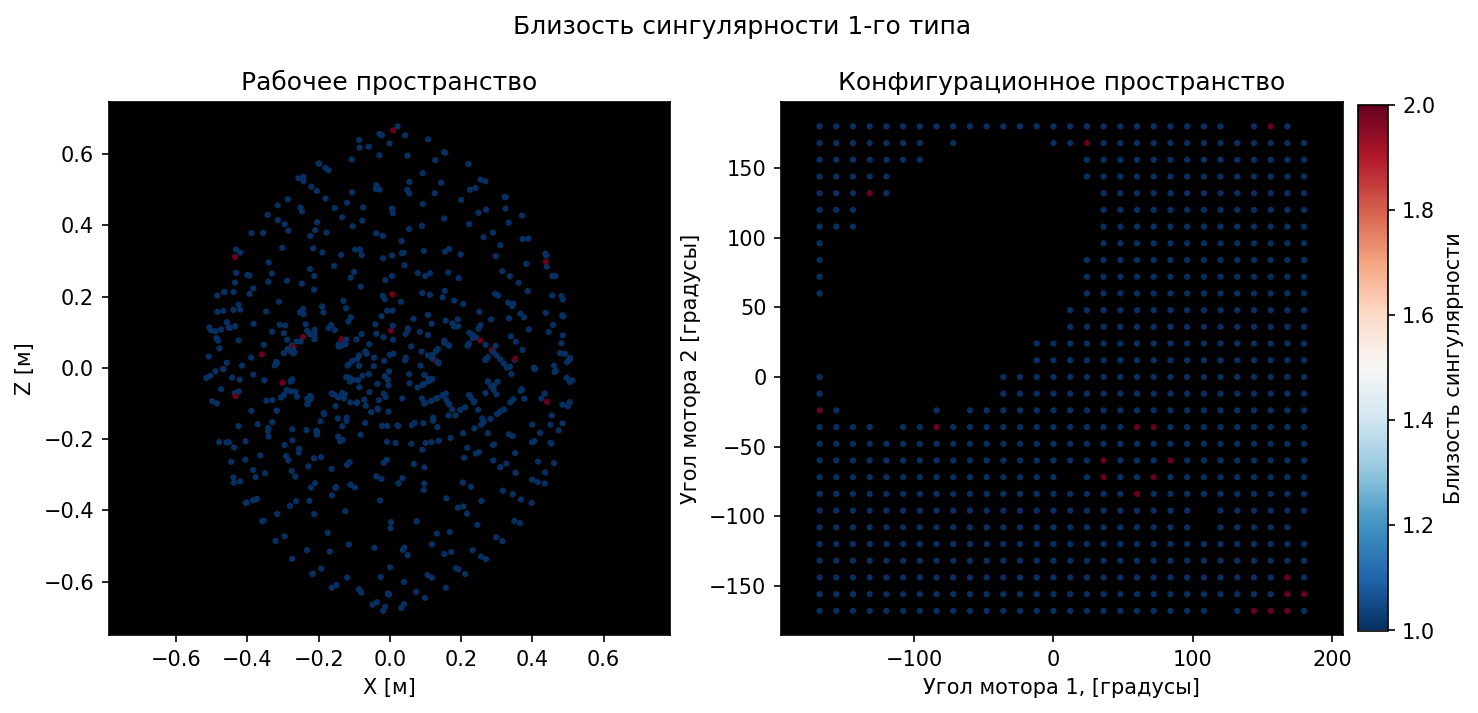

In [20]:
motorspace_q = np.asarray(available_q)[:,robo.actuation_model.idqmot]

# plot_fsing(workspace_xyz, motorspace_q, sing_prox2ik, is_log=1, color_lims=None)
# plot_fsing(workspace_xyz[maxed_idxs_ik,:], motorspace_q[maxed_idxs_ik,:], sing_prox2ik[maxed_idxs_ik], is_log=1, color_lims=[None,None],title="Близость сингулярности 1-го типа")
plot_fsing(workspace_xyz[maxed_idxs_ik,:], motorspace_q[maxed_idxs_ik,:], repeaters, is_log=0, color_lims=None,title="Близость сингулярности 1-го типа")
# plot_fsing_tall(workspace_xyz, motorspace_q, sing_prox2ik, is_log=False)

In [21]:
maxed_idxs_fk = select_max_from_repeaters(sing_prox_fk, repeaters)

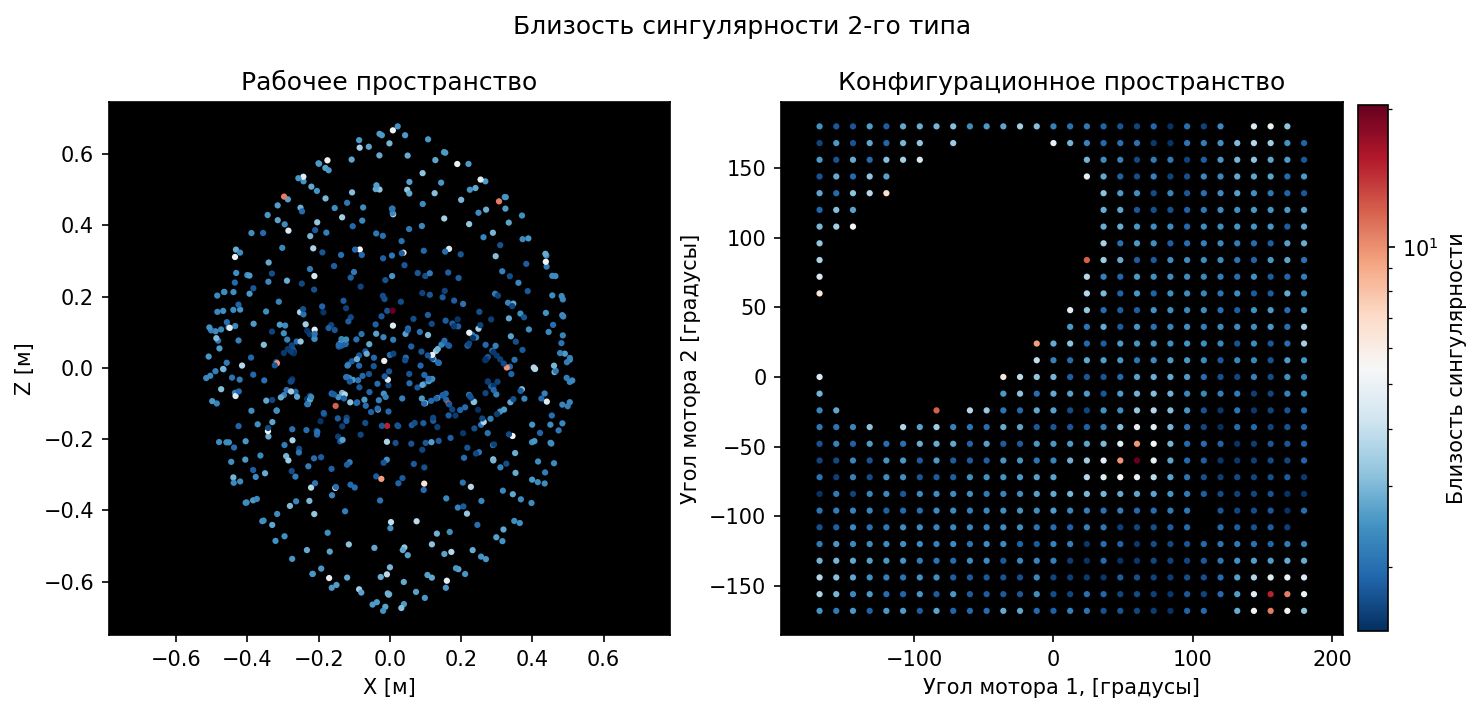

In [22]:
plot_fsing(workspace_xyz[maxed_idxs_fk,:], motorspace_q[maxed_idxs_fk,:], sing_prox_fk[maxed_idxs_fk], is_log=1, color_lims=None,title="Близость сингулярности 2-го типа")

In [23]:
print(Lambdas)

[[[ 1.89064125  1.51037893]
  [ 1.51037893  9.51332861]]

 [[ 3.45969688 -0.30853149]
  [-0.30853149  3.69687604]]

 [[ 5.50498628 -4.93913717]
  [-4.93913717 11.81896046]]

 ...

 [[ 4.28669922  6.09866216]
  [ 6.09866216 17.07241516]]

 [[ 2.56678008  2.90791434]
  [ 2.90791434  8.68934345]]

 [[ 3.58888997  8.05164076]
  [ 8.05164076 30.4735393 ]]]


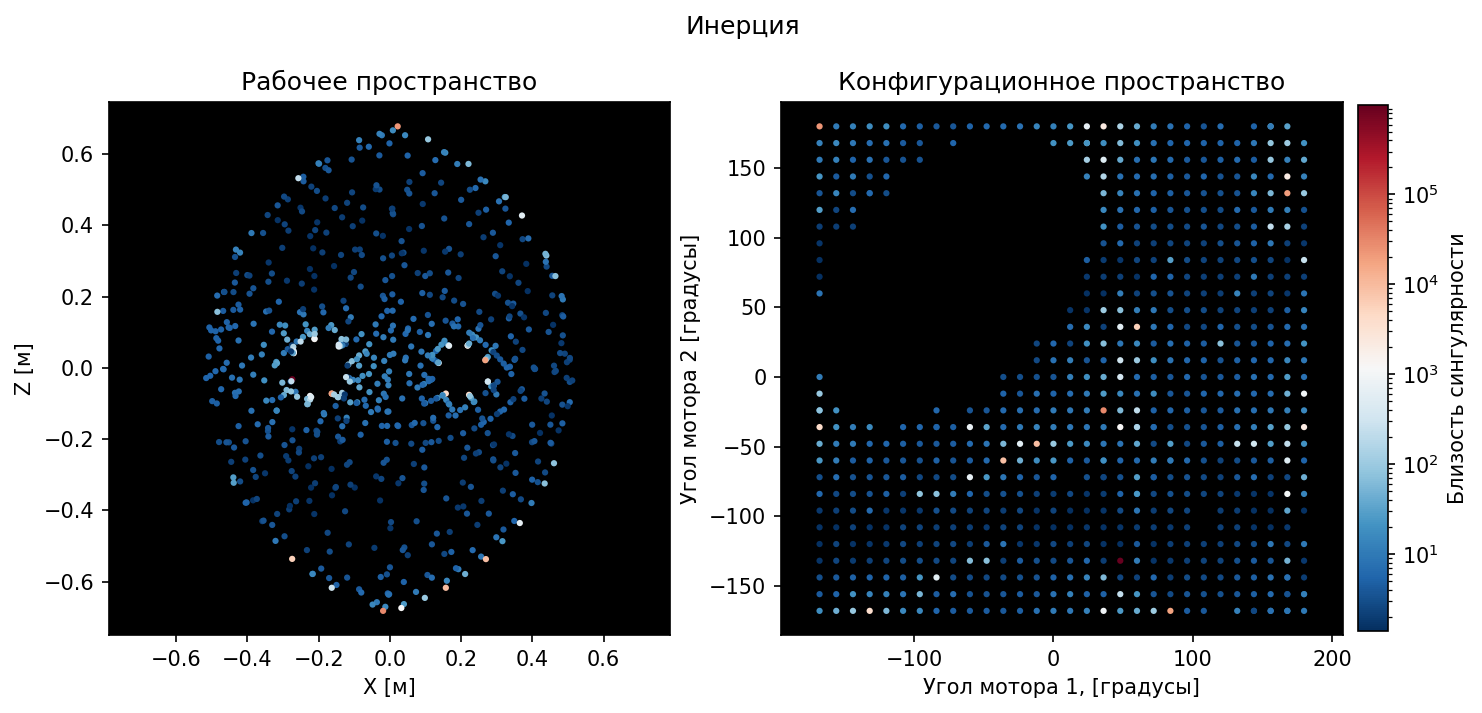

In [24]:
plot_fsing(workspace_xyz, motorspace_q, Lambdas[:,1,1], is_log=1, color_lims=None,title="Инерция")